# Best Models Reproduction: LightGBM on DMS + Fundamentals / Sentiment

- Best Val DA: LGBM, DMS + [log_mktcap, bm, roa_ttm, roe_ttm]
- Best Test DA: LGBM, DMS + [mean_sentiment]

This notebook:
1. Loads train/val/test data
2. Builds DOW+MONTH+SECTOR (DMS) one-hot features
3. Fits LightGBM with the best hyperparameters on:
    - Model A (best Val): DMS + log_mktcap + bm + roa_ttm + roe_ttm
    - Model B (best Test): DMS + mean_sentiment
4. Saves train/val/test predictions to CSV.

In [21]:
import pandas as pd
import numpy as np

from lightgbm import LGBMRegressor, early_stopping
import re

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 1. Load data

In [22]:
# %%
train = pd.read_parquet("../data/model/final_train.parquet")
val   = pd.read_parquet("../data/model/final_val.parquet")
test  = pd.read_parquet("../data/model/final_test.parquet")

print("Train Date range:", train["Date"].min(), "to", train["Date"].max())
print("Val Date range:  ", val["Date"].min(),   "to", val["Date"].max())
print("Test Date range: ", test["Date"].min(),  "to", test["Date"].max())

# Targets as 1D vectors
y_train_vec = train["return_next_day"].values.astype("float32")
y_val_vec   = val["return_next_day"].values.astype("float32")
y_test_vec  = test["return_next_day"].values.astype("float32")

# Keep (Date, tic, y) frames for saving predictions later
y_train = train[["Date", "tic", "return_next_day"]].copy()
y_val   = val[["Date", "tic", "return_next_day"]].copy()
y_test  = test[["Date", "tic", "return_next_day"]].copy()

# Features (drop target)
X_train = train.drop(columns=["return_next_day"]).copy()
X_val   = val.drop(columns=["return_next_day"]).copy()
X_test  = test.drop(columns=["return_next_day"]).copy()

Train Date range: 2016-01-04 00:00:00 to 2021-12-30 00:00:00
Val Date range:   2022-01-03 00:00:00 to 2022-12-30 00:00:00
Test Date range:  2023-01-03 00:00:00 to 2023-12-29 00:00:00


## 2. Bring in sector info

In [23]:
sp500_info = pd.read_csv("../data/sp500_companies.csv")
sector_info = (
    sp500_info[["ticker", "sector", "subsector"]]
    .rename(columns={"ticker": "tic"})
)

# Merge sector into X_*
X_train = X_train.merge(sector_info, on="tic", how="left")
X_val   = X_val.merge(sector_info, on="tic", how="left")
X_test  = X_test.merge(sector_info, on="tic", how="left")

## 3. Build DMS features (DOW + MONTH + SECTOR) & news features

In [24]:
news_features = ["mean_sentiment", "max_sentiment", "min_sentiment",
                 "sum_sentiment", "news_count"]

emb_cols = [c for c in train.columns if c.startswith("pca_emb_")]
print("Embedding columns:", len(emb_cols))


def add_news_features(df):
    """
    Safely add news momentum features WITHOUT modifying any existing columns.
    Only new lag/roll/vol/shock/surprise columns will be filled with 0.
    """
    df = df.copy()

    # Sort a temporary copy for grouped calculations (does NOT affect df order)
    tmp = df.sort_values(["tic", "Date"]).copy()
    grp = tmp.groupby("tic")

    # Dictionary to hold new features
    new_cols = {}

    for f in news_features:
        # lagged
        new_cols[f + "_lag1"] = grp[f].shift(1)

        # leak-free rolling using shifted values
        new_cols[f + "_roll3"] = grp[f].shift(1).rolling(3).mean()
        new_cols[f + "_roll5"] = grp[f].shift(1).rolling(5).mean()

        # volatility
        new_cols[f + "_vol5"] = grp[f].shift(1).rolling(5).std()

        # raw values for shock and surprise
        current_vals = tmp[f]
        lag1_vals    = new_cols[f + "_lag1"]
        roll3_vals   = new_cols[f + "_roll3"]

        new_cols[f + "_shock"] = current_vals - lag1_vals
        new_cols[f + "_surprise3"] = current_vals - roll3_vals

    # Now align new_cols to df index, and fill NaN **ONLY for new columns**
    for col, series in new_cols.items():
        series = series.reindex(df.index)    # align back to original df order
        df[col] = series.fillna(0.0)         # fill only the new column

    return df

# Add news momentum features to X_*
X_train = add_news_features(X_train)
X_val   = add_news_features(X_val)
X_test  = add_news_features(X_test)


Embedding columns: 64


In [25]:
X_train

,Date,tic,Open,High,Low,Close,Volume,sales_growth_qoq,sales_growth_ttm,asset_growth,...,sum_sentiment_roll5,sum_sentiment_vol5,sum_sentiment_shock,sum_sentiment_surprise3,news_count_lag1,news_count_roll3,news_count_roll5,news_count_vol5,news_count_shock,news_count_surprise3
0,2016-01-04,A,37.978592,38.098833,37.312624,37.636356,3287300,0.020710,-0.002470,-0.309482,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
1,2016-01-05,A,37.673370,37.876861,37.312638,37.506878,2587200,0.020710,-0.002470,-0.309482,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
2,2016-01-06,A,37.220145,37.913860,37.044401,37.673370,2103600,0.020710,-0.002470,-0.309482,...,0.0,0.0,1.574018,0.000000,0.0,0.000000,0.0,0.0,2.0,0.000000
3,2016-01-07,A,37.127663,37.136914,35.897475,36.073215,3504300,0.020710,-0.002470,-0.309482,...,0.0,0.0,-1.922346,-0.873001,2.0,0.666667,0.0,0.0,0.0,1.333333
4,2016-01-08,A,36.276692,36.729917,35.582976,35.693970,3736700,0.020710,-0.002470,-0.309482,...,0.0,0.0,0.348328,-0.408563,2.0,1.333333,0.0,0.0,-2.0,-1.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729654,2021-12-23,ZTS,232.351139,234.937094,231.380211,233.129807,1172400,0.022051,0.163387,-0.001457,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
729655,2021-12-27,ZTS,234.937073,237.176951,233.677745,236.975067,807000,0.022051,0.163387,-0.001457,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
729656,2021-12-28,ZTS,237.446137,238.253642,234.216099,234.802505,1004400,0.022051,0.163387,-0.001457,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
729657,2021-12-29,ZTS,234.581391,238.263250,234.216085,237.474960,939900,0.022051,0.163387,-0.001457,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000


In [26]:
for df in (X_train, X_val, X_test):
    df["Date"] = pd.to_datetime(df["Date"])
    df["day_of_week"] = df["Date"].dt.dayofweek  # 0=Mon,...,6=Sun
    df["month"]       = df["Date"].dt.month      # 1..12

# Categorical keys we want to one-hot
dms_cats = ["day_of_week", "month", "sector"] 

# TRAIN: define canonical DMS columns
X_train_dms = pd.get_dummies(
    X_train[dms_cats],
    columns=dms_cats,
    prefix=dms_cats,
    drop_first=True,   # gives (num_cat - 1) per category
)
dms_cols = X_train_dms.columns.tolist()

# VAL / TEST: one-hot then align to train's DMS columns
X_val_dms = pd.get_dummies(
    X_val[dms_cats],
    columns=dms_cats,
    prefix=dms_cats,
    drop_first=True,
).reindex(columns=dms_cols, fill_value=0)

X_test_dms = pd.get_dummies(
    X_test[dms_cats],
    columns=dms_cats,
    prefix=dms_cats,
    drop_first=True,
).reindex(columns=dms_cols, fill_value=0)

print("Num DOW cols:   ", sum(c.startswith("day_of_week_") for c in dms_cols))
print("Num MONTH cols: ", sum(c.startswith("month_") for c in dms_cols))
print("Num SECTOR cols:", sum(c.startswith("sector_") for c in dms_cols))
print("Total DMS cols: ", len(dms_cols))

print("X_train_dms shape:", X_train_dms.shape)
print("X_val_dms shape:  ", X_val_dms.shape)
print("X_test_dms shape: ", X_test_dms.shape)

Num DOW cols:    4
Num MONTH cols:  11
Num SECTOR cols: 10
Total DMS cols:  25
X_train_dms shape: (729659, 25)
X_val_dms shape:   (124747, 25)
X_test_dms shape:  (124727, 25)


In [27]:
# Attach DMS columns back to full design matrices
X_train_full = pd.concat([X_train.reset_index(drop=True), X_train_dms], axis=1)
X_val_full   = pd.concat([X_val.reset_index(drop=True),   X_val_dms],   axis=1)
X_test_full  = pd.concat([X_test.reset_index(drop=True),  X_test_dms],  axis=1)

In [28]:
X_train_full

,Date,tic,Open,High,Low,Close,Volume,sales_growth_qoq,sales_growth_ttm,asset_growth,...,sector_Consumer Discretionary,sector_Consumer Staples,sector_Energy,sector_Financials,sector_Health Care,sector_Industrials,sector_Information Technology,sector_Materials,sector_Real Estate,sector_Utilities
0,2016-01-04,A,37.978592,38.098833,37.312624,37.636356,3287300,0.020710,-0.002470,-0.309482,...,False,False,False,False,True,False,False,False,False,False
1,2016-01-05,A,37.673370,37.876861,37.312638,37.506878,2587200,0.020710,-0.002470,-0.309482,...,False,False,False,False,True,False,False,False,False,False
2,2016-01-06,A,37.220145,37.913860,37.044401,37.673370,2103600,0.020710,-0.002470,-0.309482,...,False,False,False,False,True,False,False,False,False,False
3,2016-01-07,A,37.127663,37.136914,35.897475,36.073215,3504300,0.020710,-0.002470,-0.309482,...,False,False,False,False,True,False,False,False,False,False
4,2016-01-08,A,36.276692,36.729917,35.582976,35.693970,3736700,0.020710,-0.002470,-0.309482,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729654,2021-12-23,ZTS,232.351139,234.937094,231.380211,233.129807,1172400,0.022051,0.163387,-0.001457,...,False,False,False,False,True,False,False,False,False,False
729655,2021-12-27,ZTS,234.937073,237.176951,233.677745,236.975067,807000,0.022051,0.163387,-0.001457,...,False,False,False,False,True,False,False,False,False,False
729656,2021-12-28,ZTS,237.446137,238.253642,234.216099,234.802505,1004400,0.022051,0.163387,-0.001457,...,False,False,False,False,True,False,False,False,False,False
729657,2021-12-29,ZTS,234.581391,238.263250,234.216085,237.474960,939900,0.022051,0.163387,-0.001457,...,False,False,False,False,True,False,False,False,False,False


## 4. LightGBM-safe column names

In [29]:
def make_lgbm_safe_colnames(cols):
    """Replace non [0-9A-Za-z_] characters with '_'."""
    return [re.sub(r"[^0-9A-Za-z_]+", "_", c) for c in cols]

orig_cols = list(X_train_full.columns)
safe_cols = make_lgbm_safe_colnames(orig_cols)
col_map   = dict(zip(orig_cols, safe_cols))

X_train_lgb = X_train_full.rename(columns=col_map)
X_val_lgb   = X_val_full.rename(columns=col_map)
X_test_lgb  = X_test_full.rename(columns=col_map)

# Also map the DMS column names and other feature names through col_map
dms_cols_safe = [col_map[c] for c in dms_cols]


## 5. Helper: directional accuracy

In [30]:
def directional_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return (np.sign(y_true) == np.sign(y_pred)).mean()

## 6. Best LightGBM hyperparameters (from DMS tuning)

In [31]:
best_lgb_dms_params = {
    "num_leaves":       63,
    "max_depth":        -1,
    "learning_rate":    0.03,
    "n_estimators":     500,
    "min_data_in_leaf": 100,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.9,
    "bagging_freq":     1,
    "device": "gpu", 
}

## 7. Generic fit-and-predict function (saves predictions)

In [32]:
def fit_lgbm_subset(
    label,
    feature_cols_orig,
    out_csv_path=None,
    params=best_lgb_dms_params,
):
    """
    Fit LightGBM on a subset of columns (given by original names),
    evaluate DA on val/test, and optionally save train/val/test predictions.
    """
    # Map original column names to safe LightGBM names
    safe_cols_subset = [col_map[c] for c in feature_cols_orig]

    Xtr = X_train_lgb[safe_cols_subset]
    Xva = X_val_lgb[safe_cols_subset]
    Xte = X_test_lgb[safe_cols_subset]

    model = LGBMRegressor(
        objective="regression",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        **params,
    )

    callbacks = [early_stopping(stopping_rounds=50, verbose=False)]

    model.fit(
        Xtr,
        y_train_vec,
        eval_set=[(Xva, y_val_vec)],
        eval_metric="rmse",
        callbacks=callbacks,
    )

    best_iter = model.best_iteration_ or params["n_estimators"]

    # Predictions
    train_pred = model.predict(Xtr, num_iteration=best_iter)
    val_pred   = model.predict(Xva, num_iteration=best_iter)
    test_pred  = model.predict(Xte, num_iteration=best_iter)

    # DA
    train_da = directional_accuracy(y_train_vec, train_pred)
    val_da   = directional_accuracy(y_val_vec,   val_pred)
    test_da  = directional_accuracy(y_test_vec,  test_pred)

    print(f"\n=== {label} ===")
    print(f"Train DA: {train_da:.6f}")
    print(f"Val   DA: {val_da:.6f}")
    print(f"Test  DA: {test_da:.6f}")

    # Save predictions if requested
    if out_csv_path is not None:
        preds_list = []

        for split_name, y_df, preds in [
            ("train", y_train, train_pred),
            ("val",   y_val,   val_pred),
            ("test",  y_test,  test_pred),
        ]:
            tmp = y_df[["Date", "tic"]].copy()
            tmp["split"]   = split_name
            tmp["y_true"]  = y_df["return_next_day"].values
            tmp["y_pred"]  = preds
            preds_list.append(tmp)

        all_preds = pd.concat(preds_list, axis=0, ignore_index=True)
        all_preds.to_csv(out_csv_path, index=False)
        print(f"Saved predictions to: {out_csv_path}")

    return {
        "label": label,
        "model": model,
        "feature_cols_orig": feature_cols_orig,
        "train_DA": train_da,
        "val_DA": val_da,
        "test_DA": test_da,
    }


## 8. Model A: Best Val DA  
**LGBM – DMS + [log_mktcap, bm, roa_ttm, roe_ttm]**  
(Val DA ≈ 0.521792 in your previous runs)

In [33]:
best_val_extra_fund_cols = ["log_mktcap", "bm", "roa_ttm", "roe_ttm"]
modelA_cols = dms_cols + best_val_extra_fund_cols

res_A = fit_lgbm_subset(
    label="LGBM_DMS_plus_log_mktcap_bm_roa_ttm_roe_ttm",
    feature_cols_orig=modelA_cols,
    out_csv_path="../data/model/preds_lgbm_best_val_DMS_plus_funds.csv",
)


[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM]

## 9. Model B: Best Test DA  
**LGBM – DMS + [mean_sentiment]**  
(Test DA ≈ 0.539771 in your previous runs)

In [34]:
best_test_sent_cols = ["mean_sentiment"]
modelB_cols = dms_cols + best_test_sent_cols

res_B = fit_lgbm_subset(
    label="LGBM_DMS_plus_mean_sentiment",
    feature_cols_orig=modelB_cols,
    out_csv_path="../data/model/preds_lgbm_best_test_DMS_plus_mean_sent.csv",
)

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM]

In [35]:
print("\nSummary:")
print(res_A)
print(res_B)


Summary:
{'label': 'LGBM_DMS_plus_log_mktcap_bm_roa_ttm_roe_ttm', 'model': LGBMRegressor(bagging_fraction=0.9, bagging_freq=1, device='gpu',
              feature_fraction=0.9, learning_rate=0.03, min_data_in_leaf=100,
              n_estimators=500, n_jobs=-1, num_leaves=63,
              objective='regression', random_state=42), 'feature_cols_orig': ['day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12', 'sector_Consumer Discretionary', 'sector_Consumer Staples', 'sector_Energy', 'sector_Financials', 'sector_Health Care', 'sector_Industrials', 'sector_Information Technology', 'sector_Materials', 'sector_Real Estate', 'sector_Utilities', 'log_mktcap', 'bm', 'roa_ttm', 'roe_ttm'], 'train_DA': np.float64(0.5383501060084231), 'val_DA': np.float64(0.5217921072250234), 'test_DA': np.float64(0.5272394910484498)}
{'label': 'LGBM_DMS_plus_mean_sentiment', '

In [36]:
news_momentum_features = []
for f in news_features:
    news_momentum_features.extend([
        f,                  # same-day sentiment
        f + "_lag1",
        f + "_roll3",
        f + "_roll5",
        f + "_vol5",
        f + "_shock",
        f + "_surprise3",
    ])
modelC_cols = dms_cols  + news_momentum_features

res_C = fit_lgbm_subset(
    label="LGBM_DMS_plus_news_momentum",
    feature_cols_orig=modelC_cols,
    out_csv_path="../data/model/preds_lgbm_best_test_DMS_plus_news_momentum.csv",
)

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM]

In [37]:
news_momentum_features = []
for f in news_features:
    news_momentum_features.extend([
        f,                  # same-day sentiment
        f + "_lag1",
        f + "_roll3",
        f + "_roll5",
        f + "_vol5",
        f + "_shock",
        f + "_surprise3",
    ])
modelD_cols = dms_cols  + news_momentum_features + emb_cols

res_D = fit_lgbm_subset(
    label="LGBM_DMS_plus_news_momentum_plus_embeddings",
    feature_cols_orig=modelD_cols,
    out_csv_path="../data/model/preds_lgbm_best_test_DMS_plus_news_momentum_plus_embeddings.csv", )

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM]

In [38]:
news_momentum_features = []
for f in news_features:
    news_momentum_features.extend([
        f,                  # same-day sentiment
        f + "_lag1",
        f + "_roll3",
        f + "_roll5",
        f + "_vol5",
        f + "_shock",
        f + "_surprise3",
    ])
modelE_cols = dms_cols  + best_test_sent_cols + emb_cols

res_E = fit_lgbm_subset(
    label="LGBM_DMS_plus_mean_sentiment_plus_embeddings",
    feature_cols_orig=modelE_cols,
    out_csv_path="../data/model/preds_lgbm_best_test_DMS_plus_mean_sentiment_plus_embeddings.csv",)

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM]

In [39]:
res_A

{'label': 'LGBM_DMS_plus_log_mktcap_bm_roa_ttm_roe_ttm',
 'model': LGBMRegressor(bagging_fraction=0.9, bagging_freq=1, device='gpu',
               feature_fraction=0.9, learning_rate=0.03, min_data_in_leaf=100,
               n_estimators=500, n_jobs=-1, num_leaves=63,
               objective='regression', random_state=42),
 'feature_cols_orig': ['day_of_week_1',
  'day_of_week_2',
  'day_of_week_3',
  'day_of_week_4',
  'month_2',
  'month_3',
  'month_4',
  'month_5',
  'month_6',
  'month_7',
  'month_8',
  'month_9',
  'month_10',
  'month_11',
  'month_12',
  'sector_Consumer Discretionary',
  'sector_Consumer Staples',
  'sector_Energy',
  'sector_Financials',
  'sector_Health Care',
  'sector_Industrials',
  'sector_Information Technology',
  'sector_Materials',
  'sector_Real Estate',
  'sector_Utilities',
  'log_mktcap',
  'bm',
  'roa_ttm',
  'roe_ttm'],
 'train_DA': np.float64(0.5383501060084231),
 'val_DA': np.float64(0.5217921072250234),
 'test_DA': np.float64(0.52723949

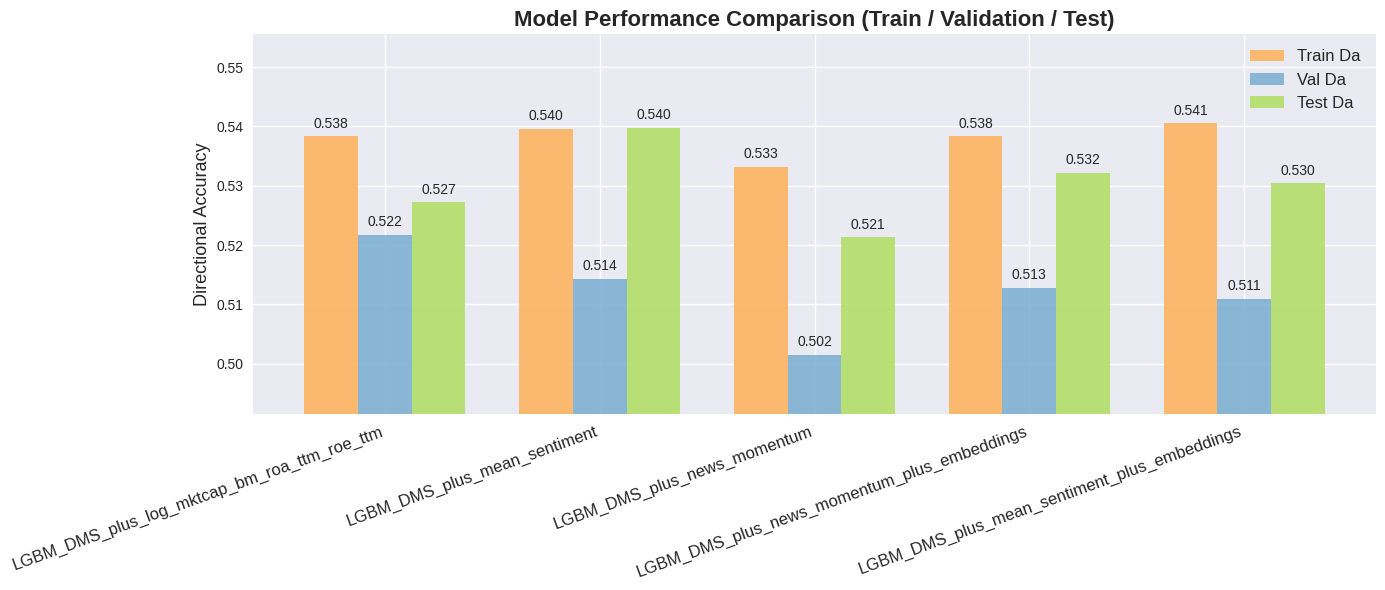

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Start from your five result dicts
# ---------------------------------------------------------
res_list = [res_A, res_B, res_C, res_D, res_E]

# Convert to DataFrame
df = pd.DataFrame(res_list)

# Metrics to plot
metrics = ["train_DA", "val_DA", "test_DA"]
labels = df["label"].tolist()

# X axis positions
x = np.arange(len(labels))
width = 0.25

plt.style.use("seaborn-v0_8")
fig, ax = plt.subplots(figsize=(14, 6))

# ---------------------------------------------------------
# Color palette (paper style)
# ---------------------------------------------------------
colors = {
    "train_DA": "#FDB462",  # orange
    "val_DA":   "#80B1D3",  # blue
    "test_DA":  "#B3DE69",  # green
}

bars = {}

# ---------------------------------------------------------
# Plot each metric (grouped bars)
# ---------------------------------------------------------
for i, metric in enumerate(metrics):
    bars[metric] = ax.bar(
        x + (i - 1)*width,
        df[metric].values,
        width,
        label=metric.replace("_", " ").title(),
        color=colors[metric],
        alpha=0.9
    )

# ---------------------------------------------------------
# Add number labels on top of bars (to 3 decimal places)
# ---------------------------------------------------------
def add_value_labels(bars):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f"{h:.3f}",                      # number shown
            xy=(bar.get_x() + bar.get_width()/2, h),
            xytext=(0, 4),                  # vertical offset
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=10, fontweight="medium"
        )

for metric in metrics:
    add_value_labels(bars[metric])

# ---------------------------------------------------------
# Axis formatting
# ---------------------------------------------------------
ax.set_ylabel("Directional Accuracy", fontsize=13)
ax.set_title("Model Performance Comparison (Train / Validation / Test)", 
             fontsize=16, weight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=12)

# Y-axis padding
ymin = df[metrics].min().min() - 0.01
ymax = df[metrics].max().max() + 0.015
ax.set_ylim(ymin, ymax)

ax.legend(fontsize=12)
plt.tight_layout()
plt.show()
